# CNNs for More Realistic Images

Real image files aren't as clean as the training images we've worked with so far. Let's get used to the...vagaries of real-world images.

## Importing Images

These are NIH images for cells infected and not infected with malaria.

In [1]:
import os

In [2]:
data_dir = os.path.join(os.getcwd(), 'cell_images')

In [3]:
os.listdir(data_dir)

['test', 'train']

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# This lets us read in image files directly.
from matplotlib.image import imread

In [6]:
test_path = os.path.join(data_dir, 'test')
train_path = os.path.join(data_dir, 'train')

In [7]:
os.listdir(test_path)

['parasitized', 'uninfected']

In [8]:
os.listdir(train_path)

['parasitized', 'uninfected']

In [9]:
os.listdir(os.path.join(train_path, 'parasitized'))[0]

'C100P61ThinF_IMG_20150918_144104_cell_162.png'

In [10]:
para_cell = os.path.join(train_path, 'parasitized', 'C100P61ThinF_IMG_20150918_144104_cell_162.png')

In [11]:
para_cell_img = imread(para_cell)

In [12]:
para_cell_img.shape

(148, 142, 3)

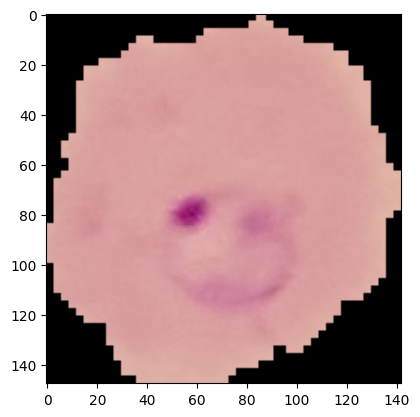

In [13]:
plt.imshow(para_cell_img)

In [14]:
os.listdir(os.path.join(train_path, 'uninfected'))[0]

'C100P61ThinF_IMG_20150918_144104_cell_128.png'

In [15]:
clean_cell = os.path.join(train_path, 'uninfected', 'C100P61ThinF_IMG_20150918_144104_cell_128.png')

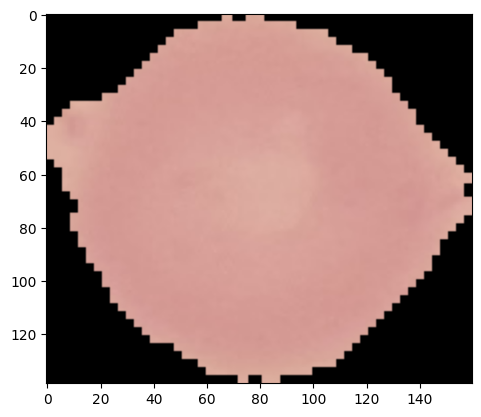

In [16]:
clean_cell_img = imread(clean_cell)
plt.imshow(clean_cell_img)

In [17]:
len(os.listdir(os.path.join(train_path, 'parasitized')))

12480

In [18]:
len(os.listdir(os.path.join(train_path, 'uninfected')))

12480

In [19]:
len(os.listdir(os.path.join(test_path, 'parasitized')))

1300

In [20]:
len(os.listdir(os.path.join(test_path, 'uninfected')))

1300

In [21]:
dim1 = []
dim2 = []

for image_filename in os.listdir(os.path.join(test_path, 'uninfected')):
    img = imread(os.path.join(test_path, 'uninfected', image_filename))
    d1, d2, _ = img.shape
    dim1.append(d1)
    dim2.append(d2)

In [22]:
dim1

[118,
 172,
 130,
 163,
 172,
 139,
 151,
 160,
 145,
 127,
 121,
 154,
 145,
 127,
 154,
 151,
 148,
 130,
 160,
 136,
 139,
 190,
 127,
 133,
 136,
 124,
 151,
 151,
 151,
 160,
 118,
 154,
 154,
 121,
 127,
 118,
 130,
 124,
 163,
 88,
 139,
 127,
 121,
 139,
 166,
 133,
 124,
 154,
 139,
 127,
 124,
 136,
 166,
 133,
 145,
 157,
 181,
 148,
 112,
 124,
 112,
 106,
 121,
 148,
 148,
 112,
 121,
 148,
 97,
 112,
 142,
 118,
 130,
 151,
 133,
 136,
 115,
 145,
 115,
 142,
 136,
 130,
 142,
 124,
 142,
 136,
 166,
 148,
 136,
 142,
 133,
 130,
 139,
 124,
 139,
 121,
 130,
 142,
 133,
 118,
 157,
 127,
 109,
 112,
 139,
 142,
 142,
 112,
 118,
 100,
 127,
 145,
 136,
 160,
 187,
 130,
 130,
 157,
 130,
 130,
 151,
 175,
 145,
 136,
 157,
 133,
 127,
 154,
 133,
 151,
 130,
 136,
 160,
 130,
 139,
 145,
 145,
 145,
 154,
 133,
 160,
 142,
 157,
 145,
 136,
 121,
 115,
 121,
 121,
 127,
 145,
 130,
 133,
 142,
 127,
 121,
 139,
 118,
 118,
 148,
 121,
 145,
 130,
 169,
 142,
 136,
 148,


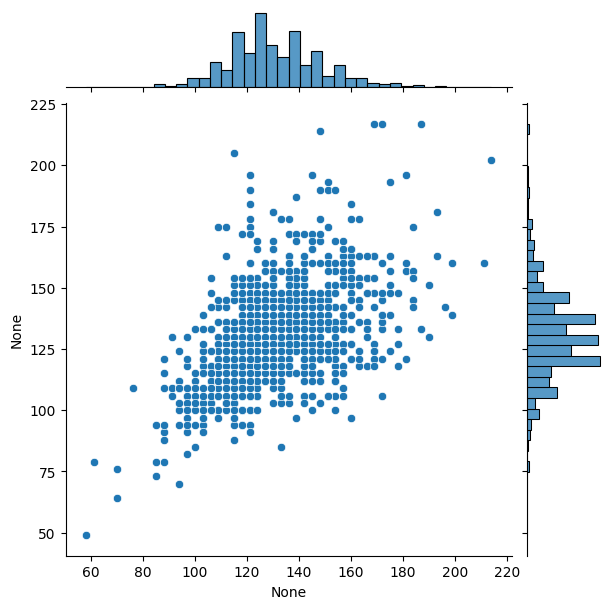

In [23]:
sns.jointplot(x=dim1, y=dim2)

**Problem:** All these pictures are a different shape.

**Solution:** I'm gonna guess padding?

In [24]:
np.mean(dim1)

np.float64(130.92538461538462)

In [25]:
np.mean(dim2)

np.float64(130.75)

In [26]:
image_shape = (130,130,3)

No, we're resizing. Huh.

## Data Processing

Time to do some image reading and manipulation.

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

C:\Users\Jay\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [28]:
help(ImageDataGenerator)

Help on class ImageDataGenerator in module keras.src.legacy.preprocessing.image:

class ImageDataGenerator(builtins.object)
 |  ImageDataGenerator(
 |      featurewise_center=False,
 |      samplewise_center=False,
 |      featurewise_std_normalization=False,
 |      samplewise_std_normalization=False,
 |      zca_whitening=False,
 |      zca_epsilon=1e-06,
 |      rotation_range=0,
 |      width_shift_range=0.0,
 |      height_shift_range=0.0,
 |      brightness_range=None,
 |      shear_range=0.0,
 |      zoom_range=0.0,
 |      channel_shift_range=0.0,
 |      fill_mode='nearest',
 |      cval=0.0,
 |      horizontal_flip=False,
 |      vertical_flip=False,
 |      rescale=None,
 |      preprocessing_function=None,
 |      data_format=None,
 |      validation_split=0.0,
 |      interpolation_order=1,
 |      dtype=None
 |  )
 |
 |  DEPRECATED.
 |
 |  Methods defined here:
 |
 |  __init__(
 |      self,
 |      featurewise_center=False,
 |      samplewise_center=False,
 |      featur

Welp, this is deprecated, so we're gonna have to do something else. Teacher's original code for reference:

```
# To increase our sample size, we can take existing images and rotate, shift, flip, etc.
# These are circular, blobby images so we can be quite liberal compared to, e.g., faces.
image_gen = ImageDataGenerator(rotation_range=90,      # degrees
                               width_shift_range=0.1,  # percentage
                               height_shift_range=0.1, # percentage
                               rescale=None,           # rescale multiplier (these are already normalized so we don't need it)
                               shear_range=0.1,        # percentage
                               zoom_range=0.1,         # percentage
                               horizontal_flip=True,
                               vertical_flip=True,
                               fill_mode='nearest'     # How do you pad the image when you've rotated, shifted, etc.?
                              )
```

In [29]:
from tensorflow.keras.utils import image_dataset_from_directory

In [97]:
train_dataset = image_dataset_from_directory(directory=train_path,
                                             color_mode='rgb',
                                             batch_size=64,
                                             image_size=image_shape[:-1]
                                            )
test_dataset = image_dataset_from_directory(directory=test_path,
                                            color_mode='rgb',
                                            batch_size=64,
                                            image_size=image_shape[:-1],
                                            shuffle=False # we don't want to mess up the order of labels when we run our conf matrix et al
                                           )

Found 24958 files belonging to 2 classes.
Found 2600 files belonging to 2 classes.


In [31]:
train_dataset.class_names

['parasitized', 'uninfected']

In [32]:
train_dataset.element_spec

(TensorSpec(shape=(None, 130, 130, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

Setting up batching.

In [33]:
from tensorflow.data import AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
train_dataset.element_spec

(TensorSpec(shape=(None, 130, 130, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [138]:
for image, label in train_dataset.take(1):
    print(image.numpy().shape)
    print(image.numpy().max())
    print(label.numpy())

(64, 130, 130, 3)
233.783
[1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 1 1 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1 0 1 1 0 0
 1 1 1 0 0 0 0 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 1 1 1 0]


## Creating the Model

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPool2D, Flatten, Dropout

In [139]:
# Trying some things since we don't have "flow from directory" and the like anymore.
from tensorflow.keras.layers import RandomRotation, RandomShear, RandomTranslation, RandomZoom, Rescaling

This time, we've got three sets of convolution/pool layers. See [this link](https://stats.stackexchange.com/questions/148139/rules-for-selecting-convolutional-neural-network-hyperparameters) for ideas on how to pick hyperparameters like this. See [here](https://www.tensorflow.org/tutorials/images/classification) for an updated tutorial, I think?

In [140]:
model = Sequential()

model.add(Input(shape=image_shape))

# Image "augmentation"
model.add(Rescaling(1./255)) # Because our images are 0-255, not 0-1.
model.add(RandomRotation(0.25)) # 0.25 * 2 * Pi = Pi / 2 = 90 degrees
model.add(RandomShear(0.1)) # percentage
model.add(RandomTranslation(height_factor=0.1, width_factor=0.1)) # percentage
model.add(RandomZoom(0.1)) # percentage

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [141]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 130, 130, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation_2 (RandomRotation)   │ (None, 130, 130, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_shear_2 (RandomShear)         │ (None, 130, 130, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_translation_2                 │ (None, 130, 130, 3)         │               0 │
│ (RandomTranslation)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom_2 (RandomZoom)           │ (None, 130, 130, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 62, 62, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 822,465 (3.14 MB)

 Trainable params: 822,465 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [142]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=2)

Once again, none of this can be used.

```
train_image_gen = image_gen.flow_from_directory(train_path,
                                                target_size=image_shape[:-1],
                                                color_mode='rgb',
                                                batch_size=64,
                                                class_mode='binary')

test_image_gen = image_gen.flow_from_directory(test_path,
                                               target_size=image_shape[:-1],
                                               color_mode='rgb',
                                               batch_size=64,
                                               class_mode='binary',
                                               shuffle=False # We don't to shuffle test data
                                              )
```

In [143]:
#results = model.fit_generator(train_image_gen, epochs=20, validation_data=test_image_gen, callbacks=[early_stop])
results = model.fit(train_dataset, validation_data=test_dataset, epochs=20, callbacks=[early_stop])

Epoch 1/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - accuracy: 0.8186 - loss: 0.3995 - val_accuracy: 0.9373 - val_loss: 0.1857
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.9250 - loss: 0.2211 - val_accuracy: 0.9354 - val_loss: 0.1905
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.9315 - loss: 0.2046 - val_accuracy: 0.9438 - val_loss: 0.1739
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.9374 - loss: 0.1925 - val_accuracy: 0.9512 - val_loss: 0.1544
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.9434 - loss: 0.1765 - val_accuracy: 0.9531 - val_loss: 0.1483
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.9460 - loss: 0.1668 - val_accuracy: 0.9527 - val_loss: 0.1395
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.9477 - loss: 0.1655 - val_accuracy: 0.9519 - val_loss: 0.1379
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.9491 - loss: 0.1572 - 

In [144]:
model_hist = pd.DataFrame(model.history.history)
model_hist

,accuracy,loss,val_accuracy,val_loss
0,0.818575,0.399473,0.937308,0.185721
1,0.924994,0.221145,0.935385,0.190500
2,0.931525,0.204639,0.943846,0.173887
3,0.937375,0.192504,0.951154,0.154424
4,0.943385,0.176489,0.953077,0.148279
5,0.946029,0.166770,0.952692,0.139512
6,0.947672,0.165468,0.951923,0.137922
7,0.949115,0.157156,0.953846,0.133823
8,0.947552,0.156274,0.953077,0.131190
9,0.948634,0.155587,0.954615,0.133694


<Axes: >

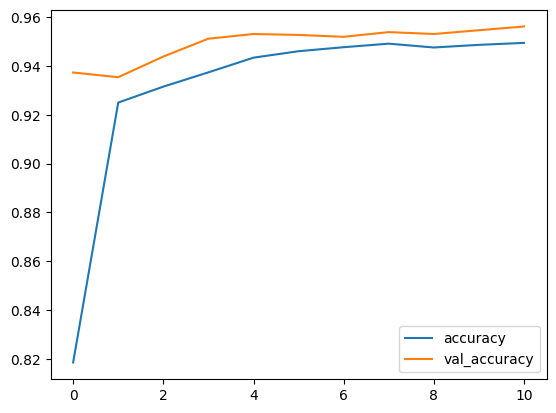

In [145]:
model_hist[['accuracy', 'val_accuracy']].plot()

<Axes: >

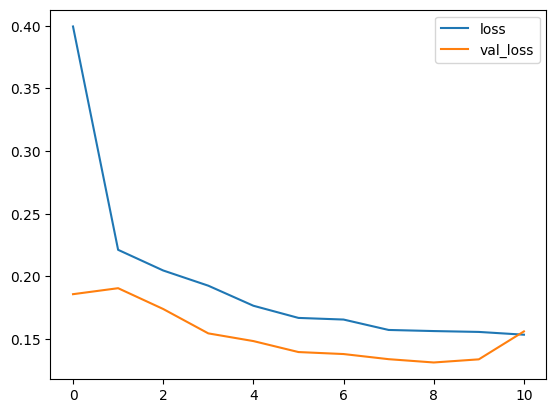

In [146]:
model_hist[['loss', 'val_loss']].plot()

## Evaluating the Model

Okay, that took a lot more effort than expected but we finally got it and close to 95% accuracy.

In [147]:
y_pred = (model.predict(test_dataset) > 0.5).astype("int8")

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [148]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [1],
       [1],
       [1]], shape=(2600, 1), dtype=int8)

In [149]:
y_test = np.concatenate([y for x, y in test_dataset]) # List comprehensions! Remember them?

In [150]:
y_test

array([0, 0, 0, ..., 1, 1, 1], shape=(2600,), dtype=int32)

In [151]:
y_pred=y_pred.reshape(-1,)

In [152]:
y_test.shape

(2600,)

In [153]:
y_pred.shape

(2600,)

In [154]:
from sklearn.metrics import classification_report, confusion_matrix

In [155]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96      1300
           1       0.94      0.97      0.96      1300

    accuracy                           0.96      2600
   macro avg       0.96      0.96      0.96      2600
weighted avg       0.96      0.96      0.96      2600



In [156]:
print(confusion_matrix(y_test, y_pred))

[[1225   75]
 [  39 1261]]


In [157]:
# We could set our confidence threshold higher.
y_pred80 = (model.predict(test_dataset) > 0.8).astype("int8").reshape(-1,)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [158]:
print(classification_report(y_test, y_pred80))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1300
           1       0.95      0.95      0.95      1300

    accuracy                           0.95      2600
   macro avg       0.95      0.95      0.95      2600
weighted avg       0.95      0.95      0.95      2600



In [159]:
print(confusion_matrix(y_test, y_pred80))

[[1241   59]
 [  70 1230]]


Time to run a prediction on a single image.

In [160]:
image,label=list(test_dataset.take(1))[0]

In [161]:
image[0].numpy().shape

(130, 130, 3)

In [162]:
label[0].numpy()

np.int32(0)

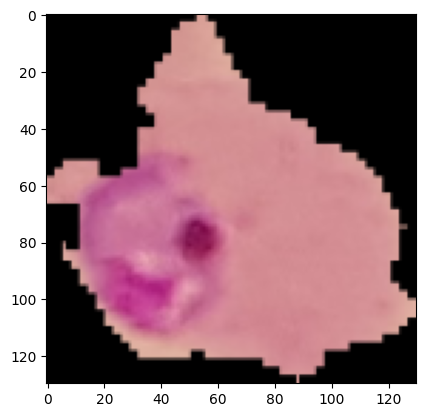

In [163]:
plt.imshow(image[0].numpy()/255)

In [165]:
# model.predict(image[0])

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 130, 3), dtype=float32) with name 'keras_tensor_212' and path ''. Expected shape (None, 130, 130, 3), but input has incompatible shape (32, 130, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 130, 3), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [242]:
image[0].shape
#tf.expand_dims(image[0], axis=0).shape

TensorShape([1, 130, 130, 3])

In [173]:
a = list(test_dataset)

In [178]:
# Batch 0, images
a[0][0].shape

TensorShape([64, 130, 130, 3])

In [179]:
# Batch 0, labels
a[0][1].shape

TensorShape([64])

In [181]:
type(a[0][0])

tensorflow.python.framework.ops.EagerTensor

In [184]:
# Batch 0, Images, Image 0
a[0][0][0].shape

TensorShape([130, 130, 3])

In [206]:
a[0][0][0].numpy()

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], shape=(130, 130, 3), dtype=float32)

Finally figured out how to do it.

In [236]:
import tensorflow as tf
test_img=tf.data.Dataset.from_tensors(tf.expand_dims(a[3][0][0], axis=0)) # EXPAND_DIMS IS WHAT I WAS LOOKING FOR

In [237]:
test_img

<_TensorDataset element_spec=TensorSpec(shape=(1, 130, 130, 3), dtype=tf.float32, name=None)>

In [239]:
(model.predict(test_img) > 0.5).astype("int8")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


array([[0]], dtype=int8)

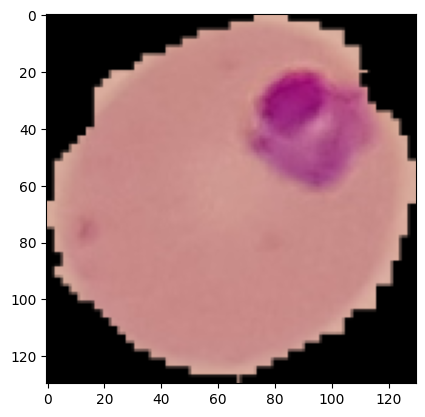

In [240]:
plt.imshow(a[3][0][0].numpy()/255)

In [243]:
image,label=list(test_dataset.take(1))[0]
test_img=tf.expand_dims(image[0], axis=0)

In [245]:
(model.predict(test_img) > 0.5).astype("int8")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([[0]], dtype=int8)

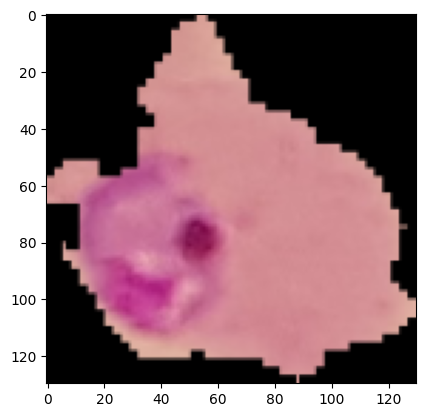

In [246]:
plt.imshow(image[0]/255)